In [1]:
%load_ext autoreload
%autoreload 2

In [433]:
###### the spreading of failures
import sys
import pickle,itertools
import requests, json
import copy
import os

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pypsa
import matplotlib.colors as mplcolors
from matplotlib.gridspec import GridSpec


from tqdm import tqdm
import statsmodels.api as sm
import seaborn as sns
from scipy import sparse
from sklearn.neighbors import KNeighborsClassifier


#from palettable.cmocean.sequential import Solar_3
#date_string = datetime.datetime.now().strftime("%I_%M_%B_%d")

path = '/media/fkaiser/'

sys.path.append(path+'Code/power-system-split/power_system_split/')
import utils,visualisation

## Evaluate component clusters based on Johannes' methods 

#### https://jugit.fz-juelich.de/network-science-group/power-system-split/-/blob/master/notebooks/evaluate_component_cluster.ipynb

In [343]:
path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'
cluster_results_path = '/media/jkruse/Projects/system_splits/power-system-split/results/'

criterion = 'nodes' # or 'load'
snet_index = 0 # only AC grid of CE
co2ls = np.arange(0.0,0.99,0.05)

n_subset_solutions = -1 # number of random sampled time steps from each co2 level simulation, -1 means all

In [344]:
# the graph G should be independent of co2l right? so that we can load it out of the loop!?
network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+'elec_s_800_ec_lv1.0_Co2L0.5-3H.nc') # +year+'/elec_s_306_ec_lv1.0_1H.nc')#
G = utils.build_networkx_graph(network, snet_index = snet_index)

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [345]:
bridges = list(nx.bridges(nx.Graph(G)))
non_bridges = list(set(list(G.edges())) - set(bridges))
n_initial_failures = len(non_bridges)

if n_subset_solutions==-1:
    n_time_stamps = network.snapshots.size
else:
    n_time_stamps = n_subset_solutions

number_of_simulations = n_initial_failures*n_time_stamps

In [ ]:
component_props = pd.DataFrame(columns= ['co2l','time_stamp', 'number_of_split', 'inertia_proxy', 'load_imbalance', 'available_flexible_generation'])
indicator_vectors = np.empty((0, len(G)),dtype = 'int')

for co2l in co2ls[::-1]:
    print('\n','CO2 level ', co2l)
    level = np.round(co2l,2)
    level_string = f'Co2L{level}'
    print(level_string)
    splitting_cascades = pickle.load(open(results_path+f'system_splits_Co2L{level}.pickle' ,'rb'))
    fname = f'Europe_Co2L{level}_split_evaluation_'+criterion+'_based_snet_%i'%snet_index+'_w_hvdc.pickle'
    solution_dict = pickle.load(open(results_path + fname,'rb'))
   
    if n_subset_solutions==-1:
        indicator_vectors_level, component_props_level = visualisation.indicator_vectors_from_rocof_solution(solution_dict,
                                                                                                             splitting_cascades,
                                                                                                             G, criterion=criterion)
    else:
        subset_of_keys = np.random.choice(list(solution_dict.keys()), n_subset_solutions, replace=False)
        subset_solution_dict = {key: solution_dict[key] for key in subset_of_keys}
        indicator_vectors_level, component_props_level = visualisation.indicator_vectors_from_rocof_solution(subset_solution_dict,
                                                                                                             splitting_cascades,
                                                                                                             G, criterion=criterion)
    indicator_vectors = np.concatenate([indicator_vectors, indicator_vectors_level])
    component_props_level.loc[:, 'co2l'] = co2l
    component_props = component_props.append(component_props_level, ignore_index=True)

  0%|          | 0/2920 [00:00<?, ?it/s]


 CO2 level  0.9500000000000001
Co2L0.95


  0%|          | 0/2920 [00:00<?, ?it/s]


 CO2 level  0.9
Co2L0.9


  0%|          | 0/2920 [00:00<?, ?it/s]

...

100%|██████████| 2920/2920 [06:29<00:00,  7.50it/s]



 CO2 level  0.25
Co2L0.25


100%|██████████| 2920/2920 [06:56<00:00,  7.00it/s]



 CO2 level  0.2
Co2L0.2


100%|█████████▉| 2906/2920 [07:27<00:04,  3.09it/s]

In [349]:
print(component_props_level)

          time_stamp  number_of_split  inertia_proxy  load_imbalance  co2l
0      01_01_2013_00              1.0   39998.562216     4213.224451  0.05
1      01_01_2013_00              1.0   10547.748000    -4289.797664  0.05
2      01_01_2013_00              2.0   48452.310216     6825.816239  0.05
3      01_01_2013_00              2.0    2009.000000    -6326.571637  0.05
4      01_01_2013_00              3.0   50546.200216    -4275.300148  0.05
...              ...              ...            ...             ...   ...
47805  31_12_2013_21             46.0       0.000000     4247.786896  0.05
47806  31_12_2013_21             48.0   75232.961659    -6478.058613  0.05
47807  31_12_2013_21             48.0       0.000000      471.871429  0.05
47808  31_12_2013_21             50.0   75202.476659   -10819.815409  0.05
47809  31_12_2013_21             50.0      30.010000     4708.634265  0.05

[47810 rows x 5 columns]


In [351]:
indicator_vectors_int = indicator_vectors.astype('int')

In [352]:
np.save(results_path + 'indicator_vectors_all_co2level_{}_based_w_hvdc.npy'.format(criterion),indicator_vectors_int)
#sparse.save_npz(results_path + 'indicator_vectors_all_co2level_{}_based_new.npz'.format(criterion), sparse_vectors)


In [353]:
component_props.to_hdf(results_path + 'split_component_properties_all_co2level_{}_based_w_hvdc.h5'.format(criterion), key='df')

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pandas/core/generic.py:2700: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block1_values] [items->Index(['time_stamp', 'available_flexible_generation'], dtype='object')]

  pytables.to_hdf(


In [8]:
#indicator_vectors = sparse.load_npz(results_path + 'indicator_vectors_all_co2level_{}_based_new.npz'.format(criterion))

In [354]:
indicator_vectors_int

array([[1, 1, 1, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 0, 0]])

In [214]:
component_props = pd.read_hdf(results_path + 'split_component_properties_all_co2level_{}_based_w_hvdc.h5'.format(criterion))

In [368]:
indices = np.arange(indicator_vectors.shape[0])
np.random.shuffle(indices)
sample_size = 0.02
test_indices = indices[:int(sample_size*indicator_vectors.shape[0])]

 #...this can take a few hours for all time steps and co2 levels
min_cluster_distance = 19./ len(G) 
n_cluster, cluster_labels = visualisation.cluster_indicator_vectors_agglomerative(indicator_vectors_int[test_indices], 
                                                                                  min_cluster_distance = min_cluster_distance,
                                                                                  cluster_distance_type = 'average')
component_props.loc[test_indices, 'cluster_label'] = cluster_labels
n_cluster

97

In [369]:
KN = KNeighborsClassifier()
KN.fit(indicator_vectors_int[test_indices],cluster_labels)
labels2 = KN.predict(indicator_vectors_int)
component_props.loc[:,'cluster_label'] = labels2

In [36]:
print(component_props.shape)
print(indicator_vectors_int.shape)
np.unique(component_props["cluster_label"])

(674723, 7)
(674723, 608)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 44, 48, 52, 53, 58, 59, 60, 61, 64,
       69, 73, 74, 76, 78, 80, 82])

In [370]:
# Add component properties
component_props.loc[:,'rocof'] = component_props.load_imbalance / component_props.inertia_proxy
component_props.loc[:, 'number_of_nodes'] = indicator_vectors.sum(1)
component_props.loc[:,'inertia_proxy'] = component_props.inertia_proxy


# Construct cluster properties and add likelihood of cluster given a certain co2 level
# (Likelihood = Prob. that split of this cluster occurs at random time and initial failure)
cluster_props = component_props.groupby(['cluster_label','co2l']).size().to_frame('counts')
cluster_props.loc[:,'likelihood'] = cluster_props.counts.div(number_of_simulations)
cluster_props.loc[:,'mean_number_of_nodes'] = component_props.groupby(['cluster_label','co2l'])['number_of_nodes'].mean()

# Count infinity rocofs and then set them no nan in component properties
cluster_props.loc[:,'number_pos_inf_rocofs'] = component_props.groupby(['cluster_label','co2l']).apply(lambda x: np.isposinf(x.rocof).sum())
cluster_props.loc[:,'number_neg_inf_rocofs'] = component_props.groupby(['cluster_label','co2l']).apply(lambda x: np.isneginf(x.rocof).sum())
component_props.loc[:,'rocof'] = component_props.loc[:,'rocof'].replace([np.inf, -np.inf], np.nan).dropna()

cluster_props.loc[:,'median_inertia_proxy'] = component_props.groupby(['cluster_label','co2l'])['inertia_proxy'].median()
cluster_props.loc[:,'upper_quantile_inertia_proxy'] = component_props.groupby(['cluster_label','co2l'])['inertia_proxy'].quantile(0.75)
cluster_props.loc[:,'lower_quantile_inertia_proxy'] = component_props.groupby(['cluster_label','co2l'])['inertia_proxy'].quantile(0.25)

# Calculate rocof statistics for each cluster given a certain co2 level
cluster_props.loc[:,'median_rocof'] = component_props.groupby(['cluster_label','co2l'])['rocof'].median()
cluster_props.loc[:,'median_pos_rocof'] = component_props[component_props.rocof>0].groupby(['cluster_label','co2l'])['rocof'].median()
cluster_props.loc[:,'mean_pos_rocof'] = (component_props[component_props.rocof>0].groupby(['cluster_label','co2l'])['rocof']).apply(lambda g: g.mean(skipna=False))
cluster_props.loc[:,'min_pos_rocof'] = component_props[component_props.rocof>0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.05) #.min()
cluster_props.loc[:,'max_pos_rocof'] = component_props[component_props.rocof>0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.95) #.max()
cluster_props.loc[:,'median_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].median().abs()
cluster_props.loc[:,'upper_quantile_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.75).abs()
cluster_props.loc[:,'lower_quantile_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.25).abs()

cluster_props.loc[:,'mean_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].apply(lambda g: g.mean(skipna=False)).abs()
cluster_props.loc[:,'max_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.05).abs() #min()
cluster_props.loc[:,'min_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.95).abs() #max()

# convert rocof to absolute rocof and save sign
component_props.loc[:,'rocof_positive'] = component_props.loc[:,'rocof']>0
component_props.loc[:,'rocof'] = component_props.loc[:,'rocof'].abs()

# this DataFrame has a Multiindex (cluster_label, co2l)
cluster_props.head()

counts  likelihood  mean_number_of_nodes  \
cluster_label co2l                                             
0             0.00      74    0.000027             86.527027   
              0.05      48    0.000017             96.208333   
              0.10      13    0.000005            109.230769   
              0.15       5    0.000002             78.800000   
              0.20      39    0.000014             82.230769   

                    number_pos_inf_rocofs  number_neg_inf_rocofs  \
cluster_label co2l                                                 
0             0.00                      0                      0   
              0.05                      0                      0   
              0.10                      0                      0   
              0.15                      0                      0   
              0.20                      0                      0   

                    median_inertia_proxy  upper_quantile_inertia_proxy  \
cluster_label co2l                                                       
0             0.00             274.98200                    439.646000   
              0.05             424.30642                   1182.869582   
              0.10             413.78400                    931.420000   
              0.15             545.68400                   4429.322329   
              0.20           25701.55000                  32481.990000   

                    lower_quantile_inertia_proxy  median_rocof  \
cluster_label co2l                                               
0             0.00                       165.600     65.998724   
              0.05                       165.116     44.888701   
              0.10                       293.520     42.851268   
              0.15                       499.468     26.339874   
              0.20                     16895.690      0.602433   

                    median_pos_rocof  mean_pos_rocof  min_pos_rocof  \
cluster_label co2l                                                    
0             0.00         66.275712       72.017324      14.492790   
              0.05         44.888701       69.315301       5.347421   
              0.10         46.134228       47.938063       4.574834   
              0.15         26.339874       25.081363       1.081816   
              0.20          0.602433       15.244211       0.386603   

                    max_pos_rocof  median_neg_rocof  upper_quantile_neg_rocof  \
cluster_label co2l                                                              
0             0.00     118.360630          8.454089                  8.454089   
              0.05     208.502594               NaN                       NaN   
              0.10      95.753364         15.106918                 15.106918   
              0.15      54.599835               NaN                       NaN   
              0.20     105.609150               NaN                       NaN   

                    lower_quantile_neg_rocof  mean_neg_rocof  max_neg_rocof  \
cluster_label co2l                                                            
0             0.00                  8.454089        8.454089       8.454089   
              0.05                       NaN             NaN            NaN   
              0.10                 15.106918       15.106918      15.106918   
              0.15                       NaN             NaN            NaN   
              0.20                       NaN             NaN            NaN   

                    min_neg_rocof  
cluster_label co2l                 
0             0.00       8.454089  
              0.05            NaN  
              0.10      15.106918  
              0.15            NaN  
              0.20            NaN

In [395]:
 # Only select cluster if there is at least one co2l with P(cluster | co2l) significantly larger than p (alpha=0.05)
# (i.e. we omit very unlikely clusters)
p = 0.0008
min_count, max_counts = sm.stats.binom_test_reject_interval(p,number_of_simulations, alternative='larger', alpha=0.05)
print('Rejected if less than', int(max_counts), 'hits in all', number_of_simulations, 'simulations')

#selected_cluster = cluster_props.index[cluster_props.counts>max_counts]
#n_selected_cluster = selected_cluster.get_level_values('cluster_label').unique().size

selected_cluster_mask = cluster_props.groupby('cluster_label').apply(lambda x: (x.counts>max_counts).any())
selected_cluster = selected_cluster_mask[selected_cluster_mask].index
n_selected_cluster = selected_cluster.size

print('Labels of selected cluster:', selected_cluster)
print('Number of selected cluster:', n_selected_cluster)

Rejected if less than 2312 hits in all 2791520 simulations
Labels of selected cluster: Int64Index([8, 12, 28, 37, 45, 46, 70], dtype='int64', name='cluster_label')
Number of selected cluster: 7


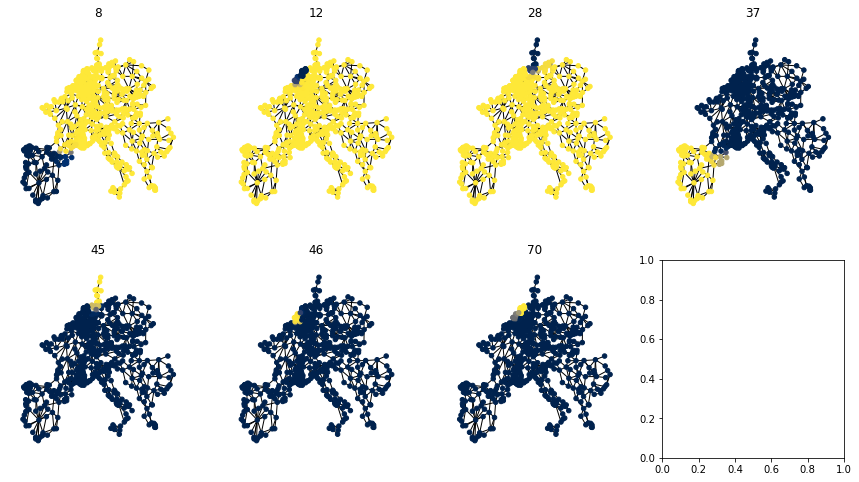

In [398]:
# Plot mean component vector of selected (cluster, co2l) samples
# (Does this make sense to only average over selected tuples?)

n_cols = 4 # adapt this value!

n_rows = np.ceil(n_selected_cluster/n_cols).astype(int)
fig,ax = plt.subplots(n_rows,n_cols,figsize = (15,4*n_rows))

#selected_components_mask = pd.MultiIndex.from_frame(component_props.loc[:,['cluster_label', 'co2l']]).isin(selected_cluster)
#selected_cluster_labels = component_props[selected_components_mask].cluster_label
#selected_ind_vectors = indicator_vectors[selected_components_mask]

selected_ind_vectors = indicator_vectors[component_props.cluster_label.isin(selected_cluster)]
selected_cluster_labels = component_props[component_props.cluster_label.isin(selected_cluster)].cluster_label

visualisation.plot_component_cluster(selected_ind_vectors,
                                     ax.flatten()[:n_selected_cluster],
                                     selected_cluster_labels.values,
                                     None,
                                     G)

In [399]:
selected_components = component_props[component_props.cluster_label.isin(selected_cluster)]
cluster_props.loc[selected_cluster]

counts  likelihood  mean_number_of_nodes  \
cluster_label co2l                                             
8             0.00    5867    0.002102            535.041589   
              0.05    4338    0.001554            535.078377   
              0.10    4298    0.001540            535.103304   
              0.15    4021    0.001440            535.187018   
              0.20    3484    0.001248            535.181114   
...                    ...         ...                   ...   
70            0.75     144    0.000052             19.666667   
              0.80     145    0.000052             19.717241   
              0.85     146    0.000052             19.623288   
              0.90     146    0.000052             19.684932   
              0.95     144    0.000052             19.479167   

                    number_pos_inf_rocofs  number_neg_inf_rocofs  \
cluster_label co2l                                                 
8             0.00                      0                      0   
              0.05                      0                      0   
              0.10                      0                      0   
              0.15                      0                      0   
              0.20                      0                      0   
...                                   ...                    ...   
70            0.75                      1                      5   
              0.80                      1                      5   
              0.85                      1                      5   
              0.90                      1                      5   
              0.95                      1                      5   

                    median_inertia_proxy  upper_quantile_inertia_proxy  \
cluster_label co2l                                                       
8             0.00          57385.676579                  64868.026070   
              0.05          74034.310118                 101351.931648   
              0.10          95332.364663                 129367.963966   
              0.15         114549.840656                 147455.625752   
              0.20         124637.248020                 163289.971419   
...                                  ...                           ...   
70            0.75           4029.000000                   7404.000000   
              0.80           4029.000000                   7404.000000   
              0.85           4029.000000                   7404.000000   
              0.90           4029.000000                   7404.000000   
              0.95           4029.000000                   6688.750000   

                    lower_quantile_inertia_proxy  median_rocof  \
cluster_label co2l                                               
8             0.00                  46685.806579      0.065031   
              0.05                  56083.398063      0.022558   
              0.10                  63389.568641     -0.005561   
              0.15                  79561.285202     -0.007045   
              0.20                  89832.925038     -0.005346   
...                                          ...           ...   
70            0.75                   2230.000000      0.028818   
              0.80                   2230.000000      0.024472   
              0.85                   2230.000000      0.135940   
              0.90                   2230.000000      0.136335   
              0.95                   2230.000000      0.028241   

                    median_pos_rocof  mean_pos_rocof  min_pos_rocof  \
cluster_label co2l                                                    
8             0.00          0.071851        0.079049       0.039404   
              0.05          0.062158        0.071845       0.026528   
              0.10          0.052685        0.063405       0.020897   
              0.15          0.043953        0.052565       0.017958   
              0.20          0.039422        0.044866  

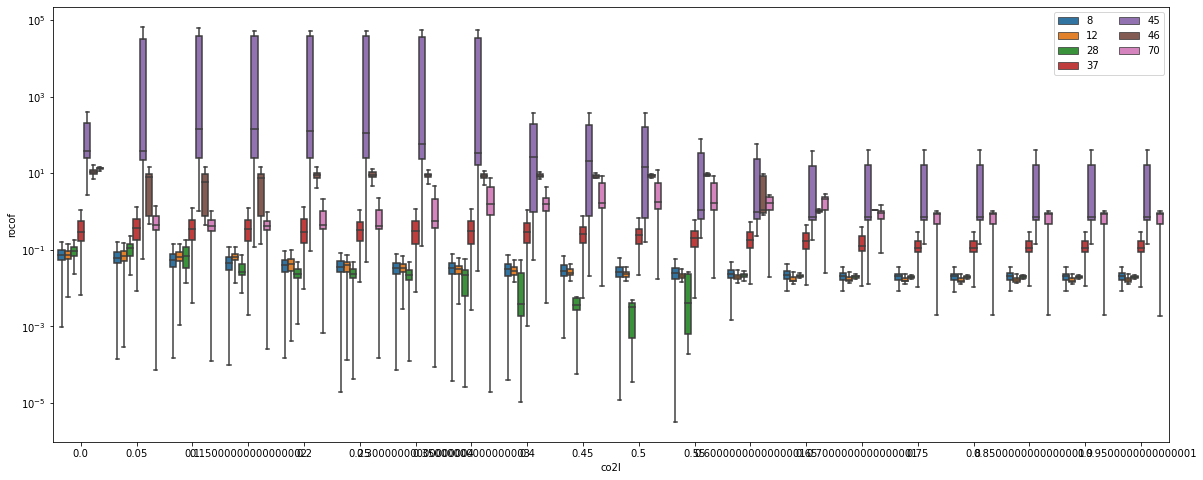

In [400]:
plt.figure(figsize=(20,8))
sns.boxplot(data=selected_components[selected_components.rocof_positive], x='co2l', y='rocof', hue='cluster_label', showfliers=False)
plt.legend(ncol=2)
#plt.xlim([-0.5,6])
plt.yscale('log') 

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8352941176470589, 0.3686274509803922, 0.0), (0.8, 0.47058823529411764, 0.7372549019607844), (0.792156862745098, 0.5686274509803921, 0.3803921568627451), (0.984313725490196, 0.6862745098039216, 0.8941176470588236), (0.5803921568627451, 0.5803921568627451, 0.5803921568627451), (0.9254901960784314, 0.8823529411764706, 0.2), (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]


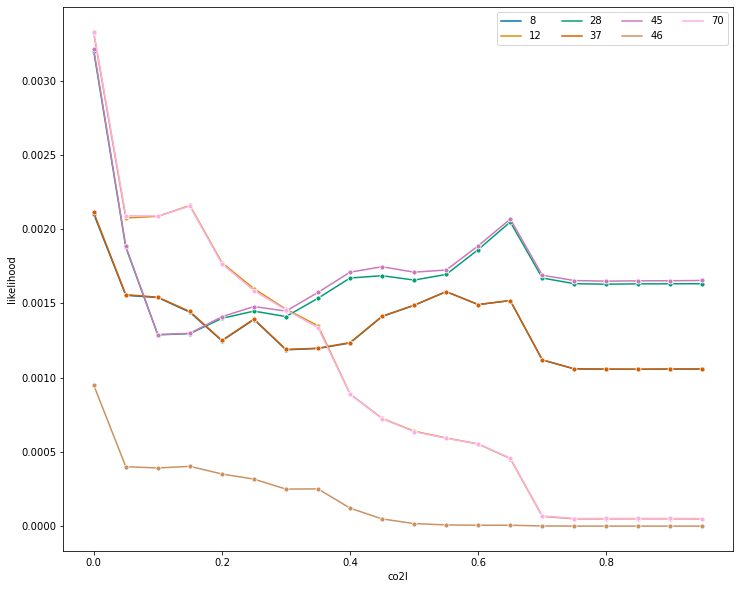

In [401]:
f,ax = plt.subplots(figsize=(12,10))

colors = sns.color_palette('colorblind')
print(colors)

sns.lineplot(data = cluster_props.loc[selected_cluster].reset_index() ,
             x = 'co2l',
             y = 'likelihood',
             hue = 'cluster_label',
             marker = '.', 
             ms = 10, 
             palette = 'colorblind')
#plt.yscale('log')
plt.legend(ncol=4)

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8352941176470589, 0.3686274509803922, 0.0), (0.8, 0.47058823529411764, 0.7372549019607844), (0.792156862745098, 0.5686274509803921, 0.3803921568627451), (0.984313725490196, 0.6862745098039216, 0.8941176470588236), (0.5803921568627451, 0.5803921568627451, 0.5803921568627451), (0.9254901960784314, 0.8823529411764706, 0.2), (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]


<AxesSubplot:xlabel='co2l', ylabel='median_neg_rocof'>

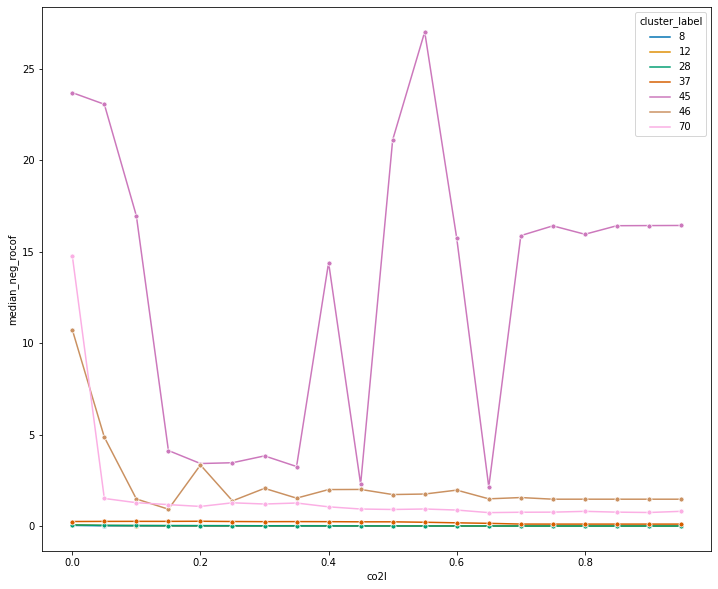

In [402]:
f,ax = plt.subplots(figsize=(12,10))

colors = sns.color_palette('colorblind')
print(colors)

sns.lineplot(data = cluster_props.loc[selected_cluster].reset_index() , 
             x = 'co2l', 
             y = 'median_neg_rocof', 
             hue = 'cluster_label', 
             marker = '.', 
             ms = 10, 
             palette = 'colorblind')#colors[:6])
#plt.yscale('log')

In [319]:
cluster_props.loc[2]

,counts,likelihood,mean_number_of_nodes,number_pos_inf_rocofs,number_neg_inf_rocofs,median_inertia_proxy,upper_quantile_inertia_proxy,lower_quantile_inertia_proxy,median_rocof,median_pos_rocof,mean_pos_rocof,min_pos_rocof,max_pos_rocof,median_neg_rocof,upper_quantile_neg_rocof,lower_quantile_neg_rocof,mean_neg_rocof,max_neg_rocof,min_neg_rocof
co2l,,,,,,,,,,,,,,,,,,,
0.00,1981,0.000710,534.991923,0,0,61210.981400,69002.644909,51185.201339,-0.018670,0.131861,0.146960,0.016438,0.337546,0.136179,0.068629,0.191837,0.134513,0.264529,0.015395
0.05,2027,0.000726,534.206216,0,0,72641.697011,99280.260017,55769.092258,-0.076428,0.105685,0.150349,0.011350,0.437859,0.108246,0.071355,0.158731,0.121942,0.253524,0.024413
0.10,1868,0.000669,533.872591,0,0,87160.441192,122236.815800,60704.253577,-0.061019,0.081541,0.120546,0.007505,0.383297,0.094843,0.058470,0.141791,0.107740,0.242243,0.014278
0.15,1835,0.000657,532.886649,0,0,96168.144706,133890.015905,69675.158777,-0.058976,0.041371,0.065737,0.002586,0.226666,0.091654,0.049698,0.140326,0.101655,0.230171,0.008222
0.20,2198,0.000787,532.819381,0,0,108233.151582,146233.146926,80585.309310,-0.065212,0.052290,0.065405,0.003812,0.182967,0.078241,0.050302,0.118051,0.090876,0.201861,0.021957
0.25,1929,0.000691,531.981337,0,0,112385.275778,144978.720245,86910.601510,-0.068756,0.046510,0.061563,0.004161,0.158105,0.074257,0.050665,0.103671,0.083355,0.175379,0.021789
0.30,2138,0.000766,532.818054,0,0,128106.424312,156903.166126,103231.862558,-0.067852,0.047353,0.054519,0.005892,0.145979,0.071288,0.050886,0.094575,0.076456,0.145842,0.025555
0.35,2121,0.000760,532.870816,0,0,126658.812995,153319.180369,103525.134653,-0.063146,0.043828,0.056031,0.005262,0.147738,0.066410,0.046654,0.091010,0.072291,0.144767,0.023450
0.40,1305,0.000467,533.752490,0,0,123885.550013,144038.495801,103056.249361,-0.059818,0.035384,0.038252,0.004675,0.092634,0.063266,0.045745,0.086826,0.068782,0.129618,0.025100


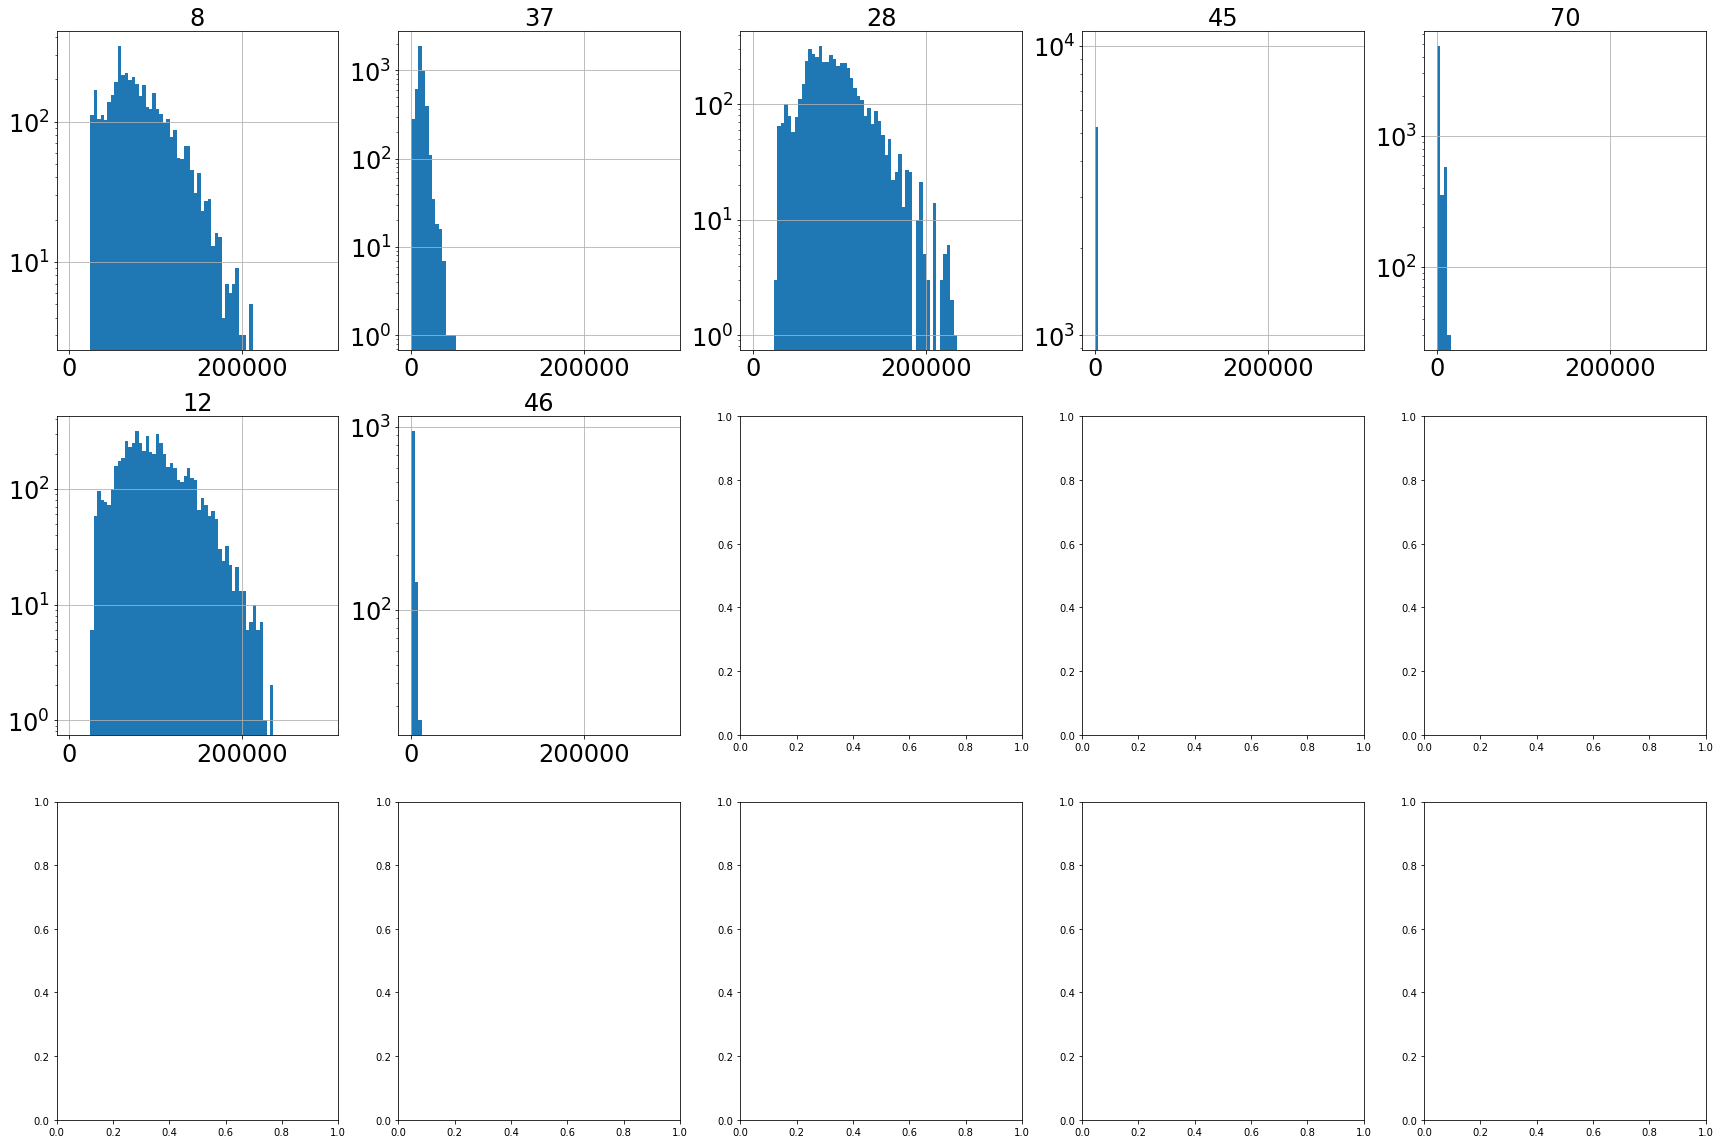

In [405]:
f,ax = plt.subplots(3,5,figsize=(24,16))
maxval = int(3e5)#4e5
bins = np.arange(0,maxval,4000)

for count,label in enumerate(selected_cluster_labels.unique()):
    
    xcoord = int(count//5)
    ycoord = int(count%5)
    
    component_props[(component_props.cluster_label==label) & (component_props.co2l==0.05)].inertia_proxy.hist(log = True, 
                                                                                                             bins = bins, 
                                                                                                             ax = ax[xcoord,ycoord])
    ax[xcoord,ycoord].set_title(label,fontsize = 24)
    ax[xcoord,ycoord].tick_params(axis = 'both', which = 'both', labelsize = 24)
plt.tight_layout()

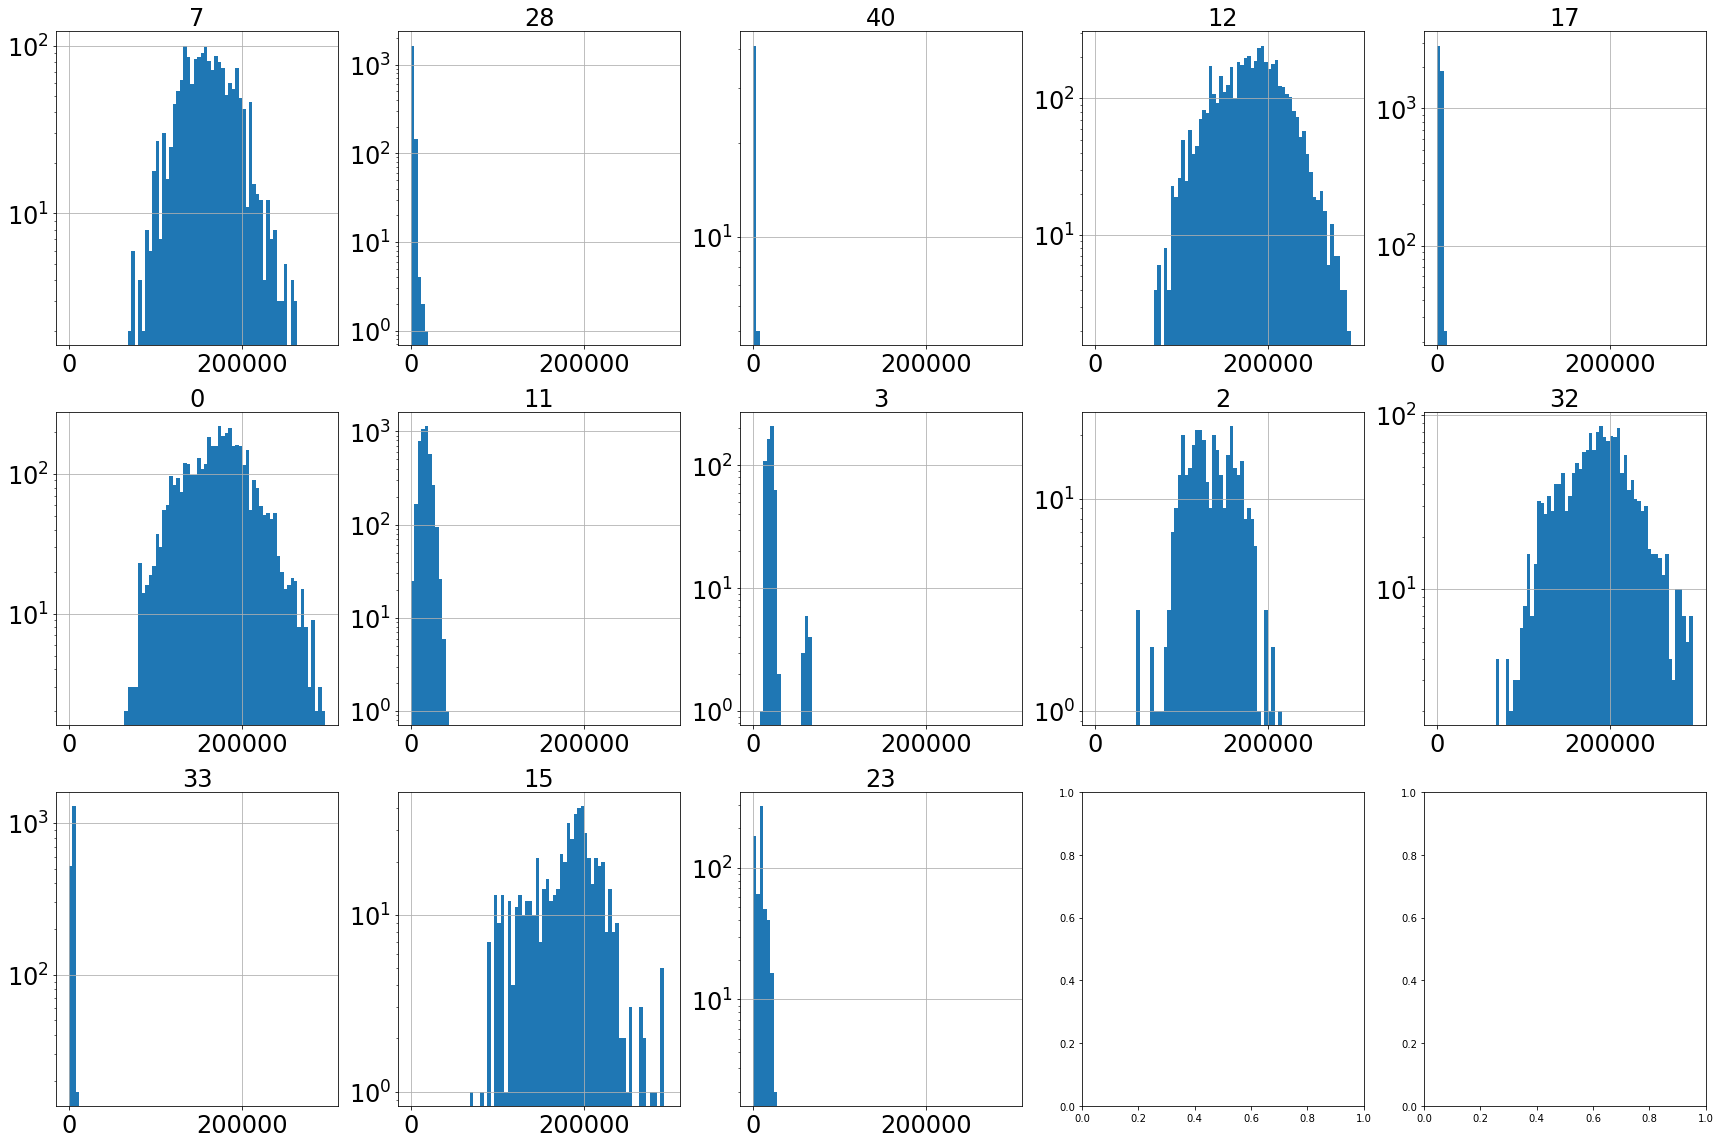

In [56]:
f,ax = plt.subplots(3,5,figsize=(24,16))
maxval = int(3e5)#4e5
bins = np.arange(0,maxval,4000)

for count,label in enumerate(selected_cluster_labels.unique()):
    
    xcoord = int(count//5)
    ycoord = int(count%5)
    
    component_props[(component_props.cluster_label==label) & (component_props.co2l==0.5)].inertia_proxy.hist(log = True, 
                                                                                                             bins = bins, 
                                                                                                             ax = ax[xcoord,ycoord])
    ax[xcoord,ycoord].set_title(label,fontsize = 24)
    ax[xcoord,ycoord].tick_params(axis = 'both', which = 'both', labelsize = 24)
plt.tight_layout()

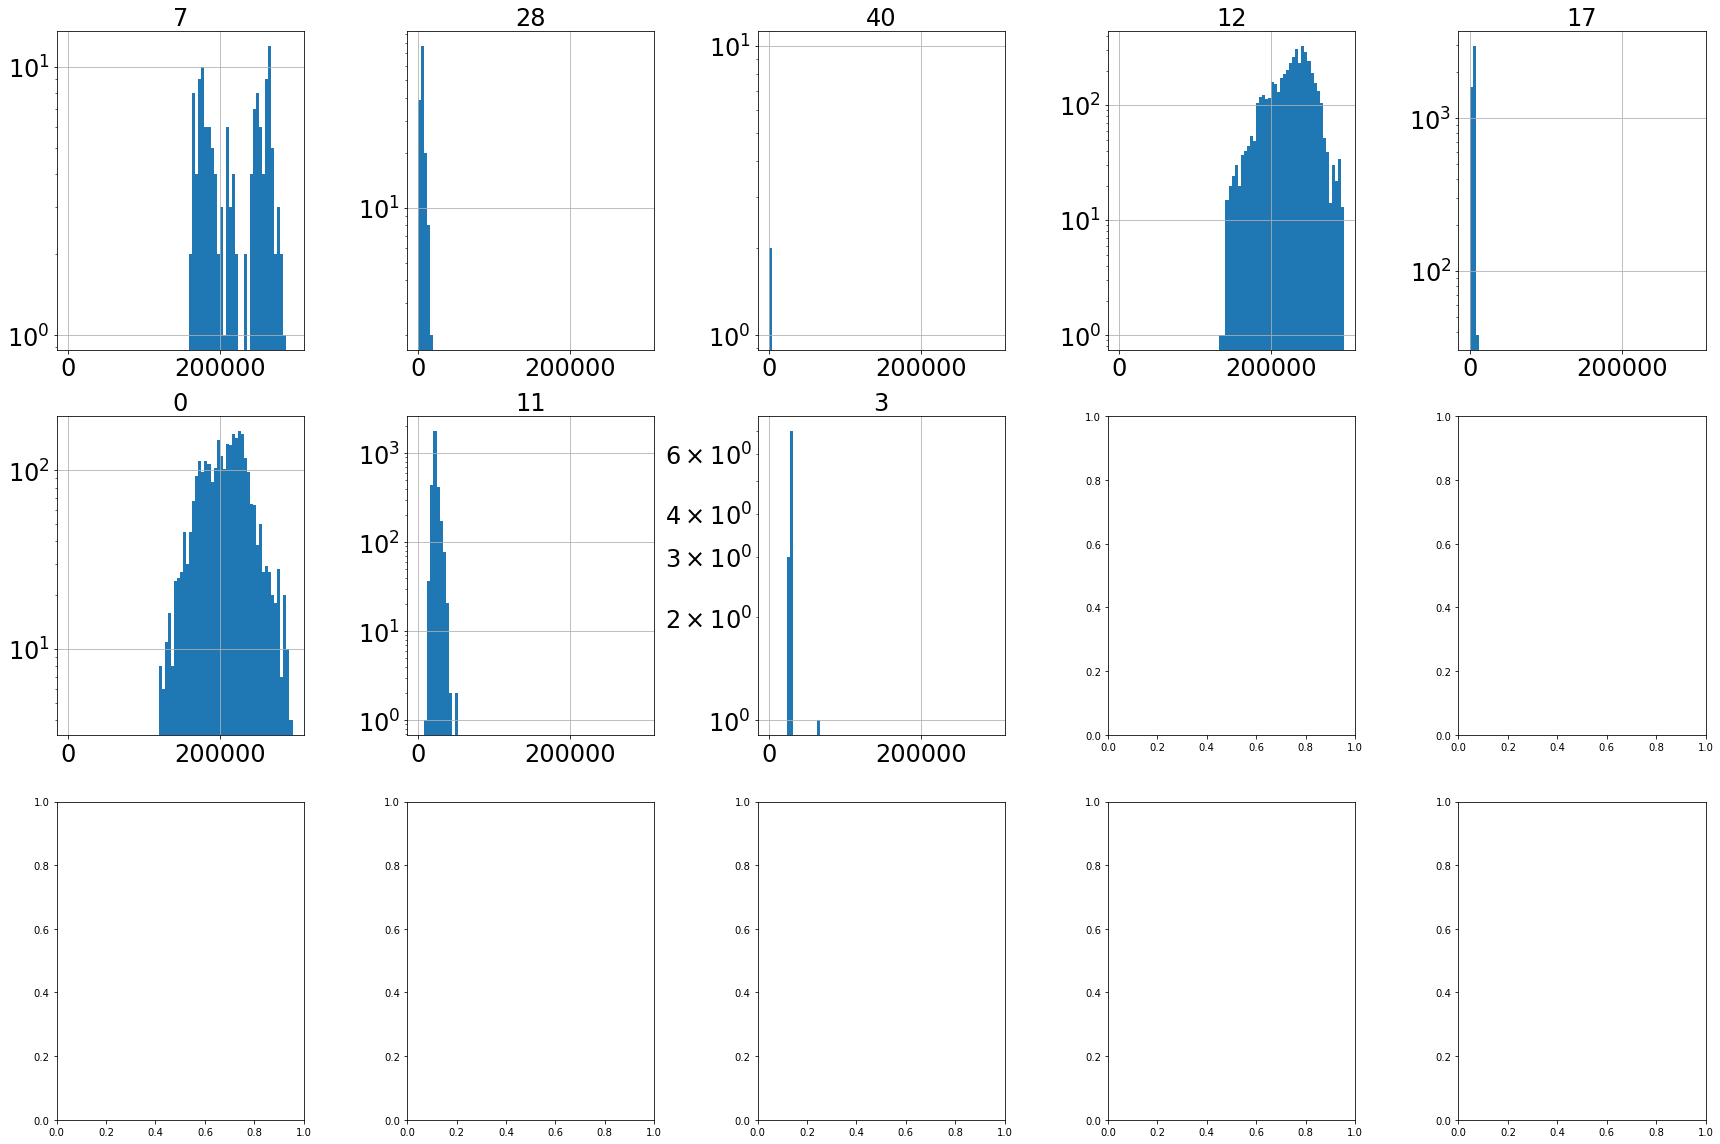

In [294]:
f,ax = plt.subplots(3,5,figsize=(24,16))
maxval = int(3e5)#4e5
bins = np.arange(0,maxval,4000)

for count,label in enumerate(selected_cluster_labels.unique()):
    
    xcoord = int(count//5)
    ycoord = int(count%5)
    
    component_props[(component_props.cluster_label==label) & (component_props.co2l==0.9)].inertia_proxy.hist(log = True, 
                                                                                                             bins = bins, 
                                                                                                             ax = ax[xcoord,ycoord])
    ax[xcoord,ycoord].set_title(label,fontsize = 24)
    ax[xcoord,ycoord].tick_params(axis = 'both', which = 'both', labelsize = 24)
plt.tight_layout()

## Visualise in likelihoode <-> rocof space

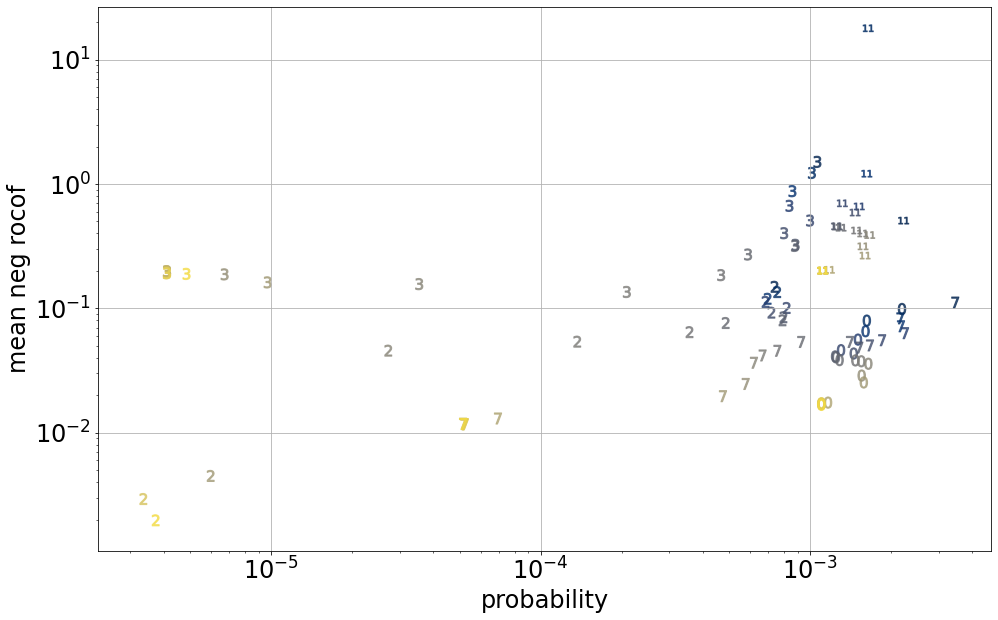

In [137]:
cmap = plt.get_cmap('cividis')
colors = [cmap(i/points.shape[0]) for i in range(points.shape[0])]
f,ax = plt.subplots(figsize = (16,10))
ax.grid(True)
indices = cluster_props.loc[selected_cluster].index.get_level_values(0).unique()


for i in range(5):
    
    points = np.array([cluster_props.loc[selected_cluster].loc[indices[i]]['likelihood'],cluster_props.loc[selected_cluster].loc[indices[i]]['mean_neg_rocof']]).T

    
    ax.scatter(points[:, 0], 
                points[:, 1],
               c = colors,
               s = 500,
               alpha = 0.7,
               marker =  TextPath((0,0), str(indices[i])),#str(indices[i]),
               label = indices[i])#, points[1:, 0]-points[:-1, 0], points[1:, 1]-points[:-1, 1])
ax.set_yscale('log')    
ax.set_xscale('log')    
ax.set_xlabel('probability', fontsize = 24)
ax.set_ylabel('mean neg rocof', fontsize = 24)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)

#ax.legend(fontsize = 24)

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8352941176470589, 0.3686274509803922, 0.0), (0.8, 0.47058823529411764, 0.7372549019607844), (0.792156862745098, 0.5686274509803921, 0.3803921568627451), (0.984313725490196, 0.6862745098039216, 0.8941176470588236), (0.5803921568627451, 0.5803921568627451, 0.5803921568627451), (0.9254901960784314, 0.8823529411764706, 0.2), (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]
8
12
28
37
45
46


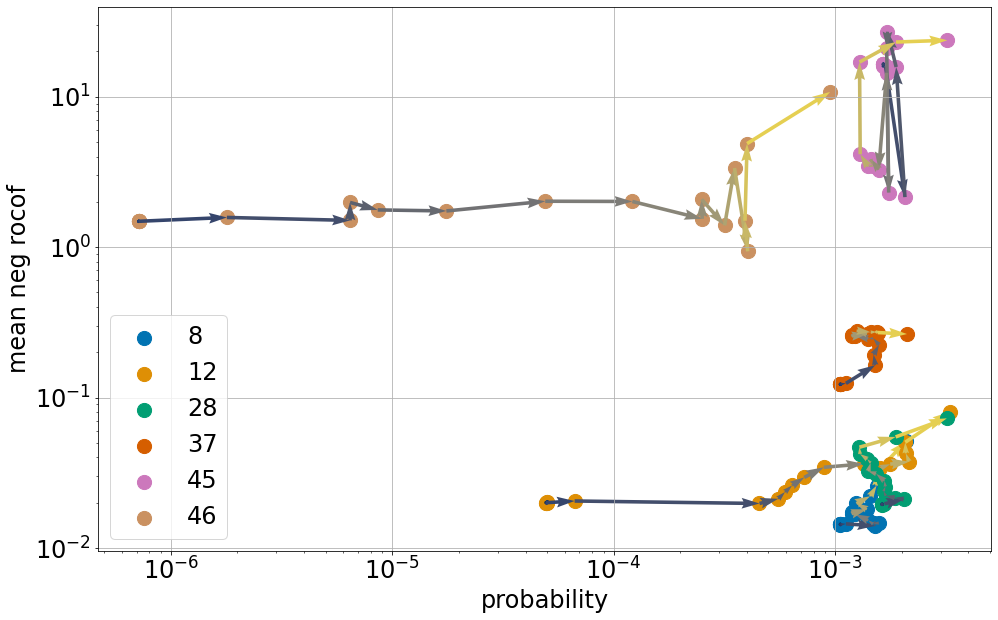

In [410]:
cmap = plt.get_cmap('cividis')

f,ax = plt.subplots(figsize = (16,10))

ax.grid(True)

indices = cluster_props.loc[selected_cluster].index.get_level_values(0).unique()

colors_points = sns.color_palette('colorblind')

print(colors_points)

for i,cluster in enumerate(selected_cluster[:6]):
    
    points = np.array([cluster_props.loc[selected_cluster].loc[indices[i]]['likelihood'],
                       cluster_props.loc[selected_cluster].loc[indices[i]]['median_neg_rocof']]).T##mean_neg_rocof

    
    colors = [cmap(i/len(co2ls)) for i in range(len(co2ls)-1)]

    ax.scatter(points[:, 0], 
               points[:, 1],
               s = 200, 
               color = colors_points[i],
              label = cluster)
    
    ax.quiver(points[1:, 0][::-1], points[1:, 1][::-1],
          (points[:-1, 0]-points[1:,0])[::-1],
          (points[:-1, 1]-points[1:,1])[::-1],
          angles = 'xy', 
          scale_units = 'xy',
          scale = 1,
          width = 0.004,
         color = colors)
    
    print(cluster)
ax.set_yscale('log')    
ax.set_xscale('log')    
ax.set_xlabel('probability', fontsize = 24)
ax.set_ylabel('mean neg rocof', fontsize = 24)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)
ax.legend(fontsize = 24)
plt.show()

8
12
28
37
45
46
70


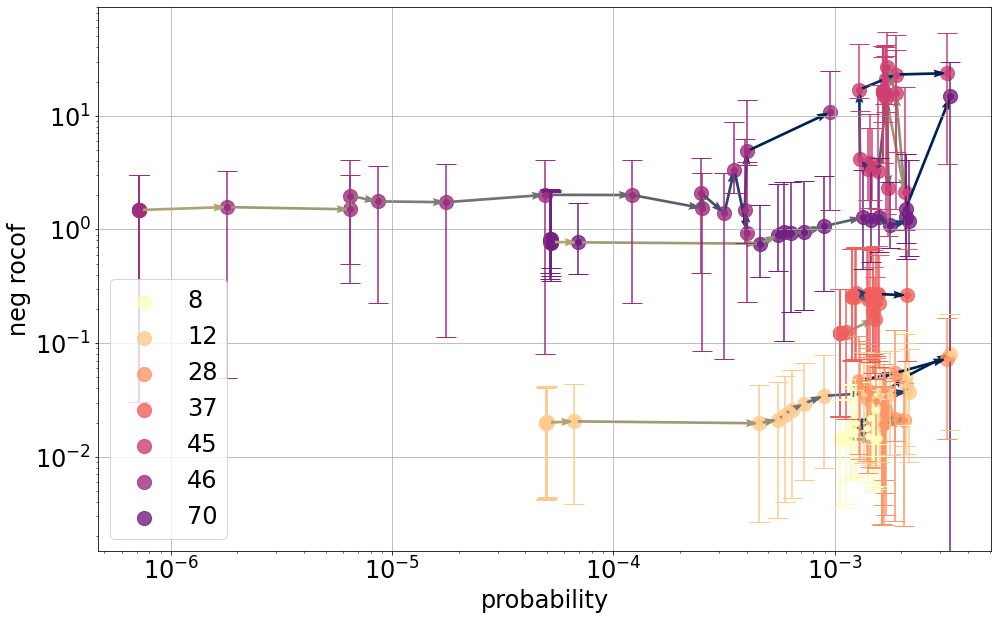

In [416]:
## cmap = plt.get_cmap('cividis')

f,ax = plt.subplots(figsize = (16,10))

ax.grid(True)

indices = cluster_props.loc[selected_cluster].index.get_level_values(0).unique()

cmap = plt.get_cmap('magma_r')

colors_points = [cmap(i/(len(selected_cluster)+2)) for i in range(len(selected_cluster))]#sns.color_palette('colorblind')


start_index = 6

cmap = plt.get_cmap('cividis')

for i,cluster in enumerate(selected_cluster[:start_index+1]):#enumerate(selected_cluster[start_index:start_index+1],start_index):
    
    points = np.array([cluster_props.loc[selected_cluster].loc[indices[i]]['likelihood'],
                       cluster_props.loc[selected_cluster].loc[indices[i]]['median_neg_rocof']]).T##mean_neg_rocof

    
    colors = [cmap(i/len(co2ls)) for i in range(len(co2ls)-1)][::-1]

    ax.scatter(points[:, 0], 
               points[:, 1],
               s = 200, 
               color = colors_points[i],
              label = cluster,
              alpha = 0.8)
    yerr = np.array([cluster_props.loc[selected_cluster].loc[indices[i]]['upper_quantile_neg_rocof'],
                     cluster_props.loc[selected_cluster].loc[indices[i]]['lower_quantile_neg_rocof']])
    #print(yerr)
    ax.errorbar(points[:, 0],
                 points[:, 1], 
                 yerr = yerr, 
                 fmt = 'o',
                color = colors_points[i],
               capsize = 10)
    
    ax.quiver(points[1:, 0][::-1], points[1:, 1][::-1],
          (points[:-1, 0]-points[1:,0])[::-1],
          (points[:-1, 1]-points[1:,1])[::-1],
          angles = 'xy', 
          scale_units = 'xy',
          scale = 1,
          width = 0.003,# 0.004,
         color = colors)
    
    print(cluster)
ax.set_yscale('log')    
ax.set_xscale('log')    
ax.set_xlabel('probability', fontsize = 24)
ax.set_ylabel('neg rocof', fontsize = 24)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)
ax.legend(fontsize = 24)
plt.show()

## Summary plot

8
12
28
37
45
46
70


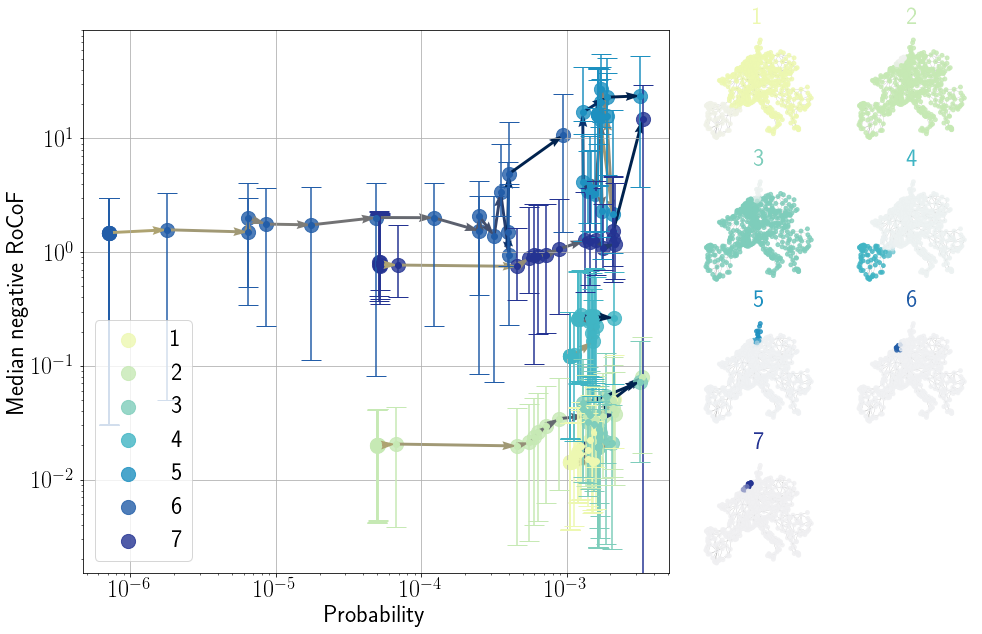

In [467]:
## cmap = plt.get_cmap('cividis')
plt.rc('text', usetex = True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

f = plt.figure(figsize = (16,10))

gs = GridSpec(4, 6, figure = f)

axs = []

for i in range(4):
    axs.append([])
    for j in range(2):
        axs[i].append(f.add_subplot(gs[i, j+4]))
        axs[i][j].axis('off')
        
ax = f.add_subplot(gs[:,:4])


ax.grid(True)

indices = cluster_props.loc[selected_cluster].index.get_level_values(0).unique()

from palettable.cartocolors.sequential import agSunset_7
from palettable.colorbrewer.sequential import YlGnBu_9

cmap = YlGnBu_9.mpl_colormap#agSunset_7.mpl_colormap #Solar_3.mpl_colormap

colors_points = [cmap((i+1)/(len(selected_cluster)+1)) for i in range(len(selected_cluster))]#sns.color_palette('colorblind')


start_index = 6


for i,cluster in enumerate(selected_cluster[:start_index+1]):#enumerate(selected_cluster[start_index:start_index+1],start_index):
    
    co2_cmap = plt.get_cmap('cividis')
    points = np.array([cluster_props.loc[selected_cluster].loc[indices[i]]['likelihood'],
                       cluster_props.loc[selected_cluster].loc[indices[i]]['median_neg_rocof']]).T##mean_neg_rocof

    
    colors = [co2_cmap(i/len(co2ls)) for i in range(len(co2ls)-1)][::-1]

    ax.scatter(points[:, 0], 
               points[:, 1],
               s = 200, 
               color = colors_points[i],
              label = str(i+1),#cluster,
              alpha = 0.8)
    yerr = np.array([cluster_props.loc[selected_cluster].loc[indices[i]]['upper_quantile_neg_rocof'],
                     cluster_props.loc[selected_cluster].loc[indices[i]]['lower_quantile_neg_rocof']])
    #print(yerr)
    #ax.errorbar(points[:, 0],
    #             points[:, 1], 
    #             yerr = yerr, 
    #             fmt = 'o',
    #            color = colors_points[i],
    #           capsize = 10)
    
    ax.quiver(points[1:, 0][::-1], points[1:, 1][::-1],
          (points[:-1, 0]-points[1:,0])[::-1],
          (points[:-1, 1]-points[1:,1])[::-1],
          angles = 'xy', 
          scale_units = 'xy',
          scale = 1,
          width = 0.005,# 0.004,
         color = colors)
    
    print(cluster)
ax.set_yscale('log')    
ax.set_xscale('log')    
ax.set_xlabel('Probability', fontsize = 24)
ax.set_ylabel('Median negative RoCoF', fontsize = 24)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)#
ax.legend(fontsize = 24)

#########################################

    
node_positions = nx.get_node_attributes(G,'pos')
    
sorted_labels = np.unique(selected_cluster_labels.values)

for i, label in enumerate(sorted_labels):
    xcoord = int(i//2)
    ycoord = int(i%2)
    cmap2 = sns.light_palette(cmap((i+1)/(len(selected_cluster)+1)), as_cmap=True)
    
    mean_ind_vector = np.array([selected_ind_vectors[selected_cluster_labels.values == label].mean(0) ])

    nx.draw(G,
            pos = node_positions,
            node_size = 15,
            width = 0.1,
            alpha = 0.8,
            ax = axs[xcoord][ycoord],
            node_color = mean_ind_vector,
            cmap = cmap2,
            vmin = 0,
            vmax = 1)


    axs[xcoord][ycoord].set_title('{}'.format(str(i+1)), #label
                                  fontsize = 24,
                                 color = cmap((i+1)/(len(selected_cluster)+1)))

path = '/media/fkaiser/'
save_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'

plt.savefig(save_path+'Figures/Figure6_risk_probability_plot_w_errorbars.pdf',bbox_inches = 'tight')

plt.show()